# Networks Analysis

In [372]:
import pypsa
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import cartopy.crs as ccrs
import os
from matplotlib.colors import Normalize, TwoSlopeNorm

### Choose the networks to analyse

In [373]:
home = "/home/lucakristin/Desktop/my_pypsa"
cluster = "450"
folder = "germany_scenario2040-TP_"

### Create folder and paths

In [374]:
# Create analysis output directory and logging file
analysis_dir = f"{home}/pypsa-eur/analysis/{folder}"
os.makedirs(analysis_dir, exist_ok=True)
log_file = os.path.join(analysis_dir, "summary.txt")

# Initialize/clear the log file with header
with open(log_file, "w") as _f:
    _f.write(f"Networks comparison summary\n")

def log_print(*args, sep=' ', end='\n', also_print=True):
    """Helper to print and append to the summary log"""
    s = sep.join(str(a) for a in args) + end
    if also_print:
        print(*args, sep=sep, end=end)
    with open(log_file, 'a') as _f:
        _f.write(s)

def save_fig(fig, name, dpi=150):
    """Helper to save a matplotlib figure into the analysis folder"""
    fname = os.path.join(analysis_dir, name)
    fig.savefig(fname, bbox_inches='tight', dpi=dpi)
    log_print(f"Saved figure: {fname}")

### Set paths

In [375]:
# Paths to the three networks
network_paths = {
    "windy": f"{home}/pypsa-eur/results/{folder}windy/networks/base_s_{cluster}_elec_.nc",
    "notwindy": f"{home}/pypsa-eur/results/{folder}notwindy/networks/base_s_{cluster}_elec_.nc",
    "windvariability": f"{home}/pypsa-eur/results/{folder}windvariability/networks/base_s_{cluster}_elec_.nc"
}

# Load the networks
networks = {name: pypsa.Network(path) for name, path in network_paths.items()}
n1 = networks["windy"]
n2 = networks["notwindy"]
n3 = networks["windvariability"]

n1.name = "Windy"
n2.name = "Not Windy"
n3.name = "Wind Variability"

INFO:pypsa.network.io:New version 1.2.2 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.2 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.2 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks


In [378]:
carrier_display_names = {
    "onwind": "Onshore wind",
    "offwind-ac": "Offshore wind (AC)",
    "offwind-float": "Offshore wind (floating)",
    "solar": "Solar PV",
    "solar-hsat": "Solar PV (high satellite)",
    "hydro": "Hydro",
    "ror": "Run-of-river",
    "lignite": "Lignite",
    "coal": "Coal",
    "oil": "Oil",
    "OCGT": "OCGT",
    "CCGT": "CCGT",
    "biomass": "Biomass",
    "waste": "Waste",
    "geothermal": "Geothermal",
    "load": "Unserved Load",
    "battery discharge": "Battery discharge",
}

def carrier_label(name):
    return carrier_display_names.get(name, name)

## Check

### Installed capacities 

In [ ]:
component_specs = [("generators", "p_nom_opt"), ("storage_units", "p_nom_opt"), ("links", "p_nom_opt")]

for network_name, network in networks.items():
    carrier_capacity = pd.Series(dtype=float)

    for component_name, capacity_column in component_specs:
        component = getattr(network, component_name, None)
        if component is None or component.empty or "carrier" not in component.columns or capacity_column not in component.columns:
            continue
        carrier_capacity = carrier_capacity.add(component.groupby("carrier")[capacity_column].sum(), fill_value=0)

    carrier_capacity = carrier_capacity.sort_values(ascending=False)
    print(f"\n{network.name} installed capacity by carrier [MW]")
    if carrier_capacity.empty:
        print("  No carrier capacity found.")
    else:
        print(carrier_capacity.to_string(float_format=lambda value: f"{value:.2f}"))


Windy installed capacity by carrier [MW]
carrier
load                       inf
solar                367000.00
onwind               209000.00
offwind-ac            66000.00
DC                    38000.00
CCGT                  29000.00
PHS                    7361.72
OCGT                   6112.74
ror                    6000.00
battery discharger     4790.97
battery charger        4694.17
waste                  3127.66
biomass                3000.00
hydro                   402.24
H2 Fuel Cell            106.14
geothermal               26.90
H2 Electrolysis          14.81
lignite                   0.00
coal                      0.00
oil                       0.00
offwind-float             0.00
offwind-dc                0.00
solar-hsat                0.00

Not Windy installed capacity by carrier [MW]
carrier
load                       inf
solar                367000.00
onwind               209000.00
battery discharger   103157.84
battery charger      101073.62
offwind-ac            66000.

### Line extension

In [380]:
for network in networks.values():
    log_print(f"\n{network.name} line capacities:")
    if "s_nom_opt" in network.lines and not network.lines.s_nom.equals(network.lines.s_nom_opt):
        log_print("  Line extension detected: 's_nom_opt' differs from 's_nom'.")
    else:
        log_print("  No line extension detected")


Windy line capacities:
  No line extension detected

Not Windy line capacities:
  No line extension detected

Wind Variability line capacities:
  No line extension detected


### Coal price 

In [381]:
carrier_name = "coal"

for network in networks.values():
    if hasattr(network, "generators"):
        g = network.generators
        if "carrier" in g.columns and "marginal_cost" in g.columns:
            mask = g["carrier"] == carrier_name
            if mask.any():
                original_costs = g.loc[mask, "marginal_cost"].copy()
                print(f"Marginal costs for '{carrier_name}' generators in {network.name} from {original_costs.iloc[0]:.2f}")
            else:
                print(f"No '{carrier_name}' generators found to modify costs.")

Marginal costs for 'coal' generators in Windy from 20.60
Marginal costs for 'coal' generators in Not Windy from 20.60
Marginal costs for 'coal' generators in Wind Variability from 20.60


### Components

In [382]:
log_print("\n=== Network Statistics ===")
for n in networks.values():
    log_print(f"\nNetwork: {n.name}")
    for dfname in ["buses","lines","generators","loads","links","storage_units","stores"]:
        if hasattr(n, dfname):
            log_print(f"  {dfname}: {len(getattr(n, dfname))}")


=== Network Statistics ===

Network: Windy
  buses: 1350
  lines: 642
  generators: 4655
  loads: 450
  links: 1818
  storage_units: 61
  stores: 900

Network: Not Windy
  buses: 1350
  lines: 642
  generators: 4655
  loads: 450
  links: 1818
  storage_units: 61
  stores: 900

Network: Wind Variability
  buses: 1350
  lines: 642
  generators: 4655
  loads: 450
  links: 1818
  storage_units: 61
  stores: 900


### Grid Congestion and Curtailment

/home/lucakristin/miniconda3/envs/pypsa-eur/lib/python3.13/site-packages/matplotlib/colors.py:2295: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)
/home/lucakristin/miniconda3/envs/pypsa-eur/lib/python3.13/site-packages/matplotlib/colors.py:2295: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)
/home/lucakristin/miniconda3/envs/pypsa-eur/lib/python3.13/site-packages/matplotlib/colors.py:2295: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)


Saved figure: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/analysis/germany_scenario2040-TP_/LINE_LOADING_ONLY.png


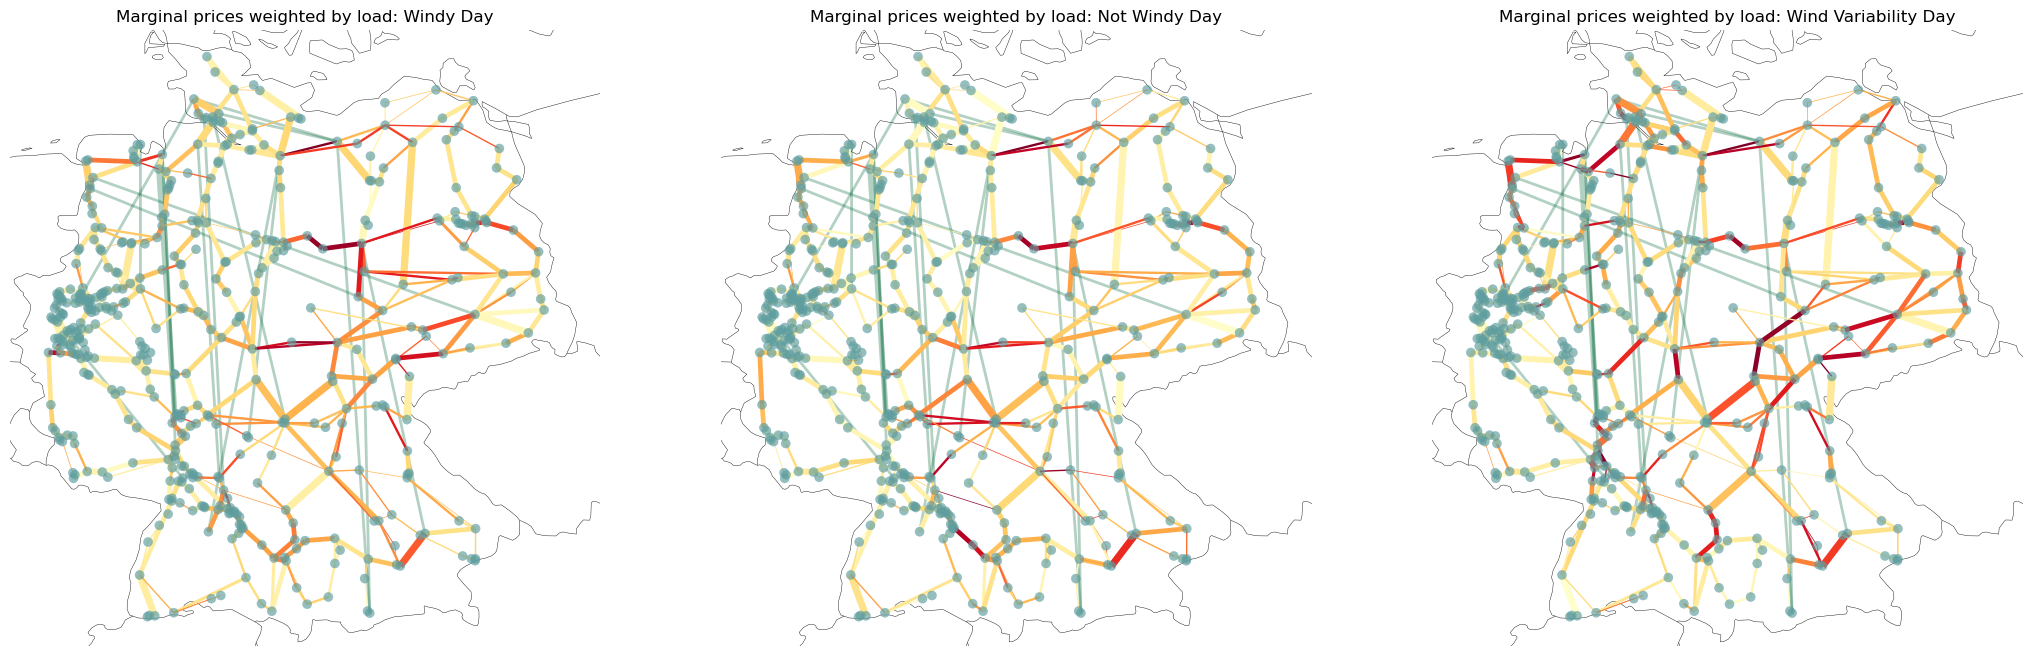

In [ ]:
# --- Create enhanced visualization ---
fig, axes = plt.subplots(1, 3, figsize=(26, 8), subplot_kw={"projection": ccrs.EqualEarth()})
fig.suptitle(f"Grid Congestion Analysis ({folder})", fontsize=16)

# --- Helper Function to Plot Network with Average Loading ---
def plot_network_congestion(n, ax, title):
    avg_loading_n = (n.lines_t.p0.abs() / n.lines.s_nom).mean()
    avg_loading_links = (n.links_t.p0.abs() / n.links.p_nom).mean()
    
    n.plot(
        ax=ax,
        geomap=True,
        title=title,
        bus_sizes=0.005,
        bus_alpha=0.3,
        line_colors=avg_loading_n,
        link_colors=avg_loading_links,
        line_cmap="YlOrRd",
        link_cmap="RdYlGn_r",
        link_alpha=0.3,
        line_width=n.lines.s_nom / 1000,
        link_width=n.links.p_nom / 1000,
    )

# Plot Average Loading Over All Snapshots for each network
i = 0
for n in networks.values():
    peak_prices = plot_network_congestion(n, axes[i], "Marginal prices weighted by load: " + n.name + " Day")
    i += 1

fig.tight_layout(rect=[0, 0, 1, 0.96])
save_fig(fig, "LINE_LOADING_ONLY.png")

Plotting 'Windy' network at time 2025-10-26 08:00:00 with peak marginal price 81.06 €/MWh
Minimum marginal price across all buses at peak time: -8.36 €/MWh


/home/lucakristin/miniconda3/envs/pypsa-eur/lib/python3.13/site-packages/matplotlib/colors.py:2295: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)
/home/lucakristin/miniconda3/envs/pypsa-eur/lib/python3.13/site-packages/matplotlib/colors.py:2295: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)



Windy Marginal Price Statistics:
count    1350.000000
mean        6.577958
std        10.337579
min        -8.363250
25%         0.025995
50%         0.056539
75%        12.750287
max        81.063886
Peak marginal price range: -8.36 to 81.06 €/MWh

Plotting 'Not Windy' network at time 2025-04-08 19:00:00 with peak marginal price 10000.01 €/MWh
Minimum marginal price across all buses at peak time: 11.65 €/MWh

Not Windy Marginal Price Statistics:
count     1350.000000
mean        75.929135
std        516.990197
min         11.652290
25%         33.000476
50%         44.360346
75%         46.996999
max      10000.009907
Peak marginal price range: 11.65 to 10000.01 €/MWh

Plotting 'Wind Variability' network at time 2025-10-06 05:00:00 with peak marginal price 10000.01 €/MWh
Minimum marginal price across all buses at peak time: -28.75 €/MWh


/home/lucakristin/miniconda3/envs/pypsa-eur/lib/python3.13/site-packages/matplotlib/colors.py:2295: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)



Wind Variability Marginal Price Statistics:
count     1350.000000
mean      1046.421591
std       2305.603622
min        -28.749948
25%          2.516078
50%         36.753330
75%         81.345434
max      10000.010692
Peak marginal price range: -28.75 to 10000.01 €/MWh

Saved figure: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/analysis/germany_scenario2040-TP_/marginal_prices_weighted.png


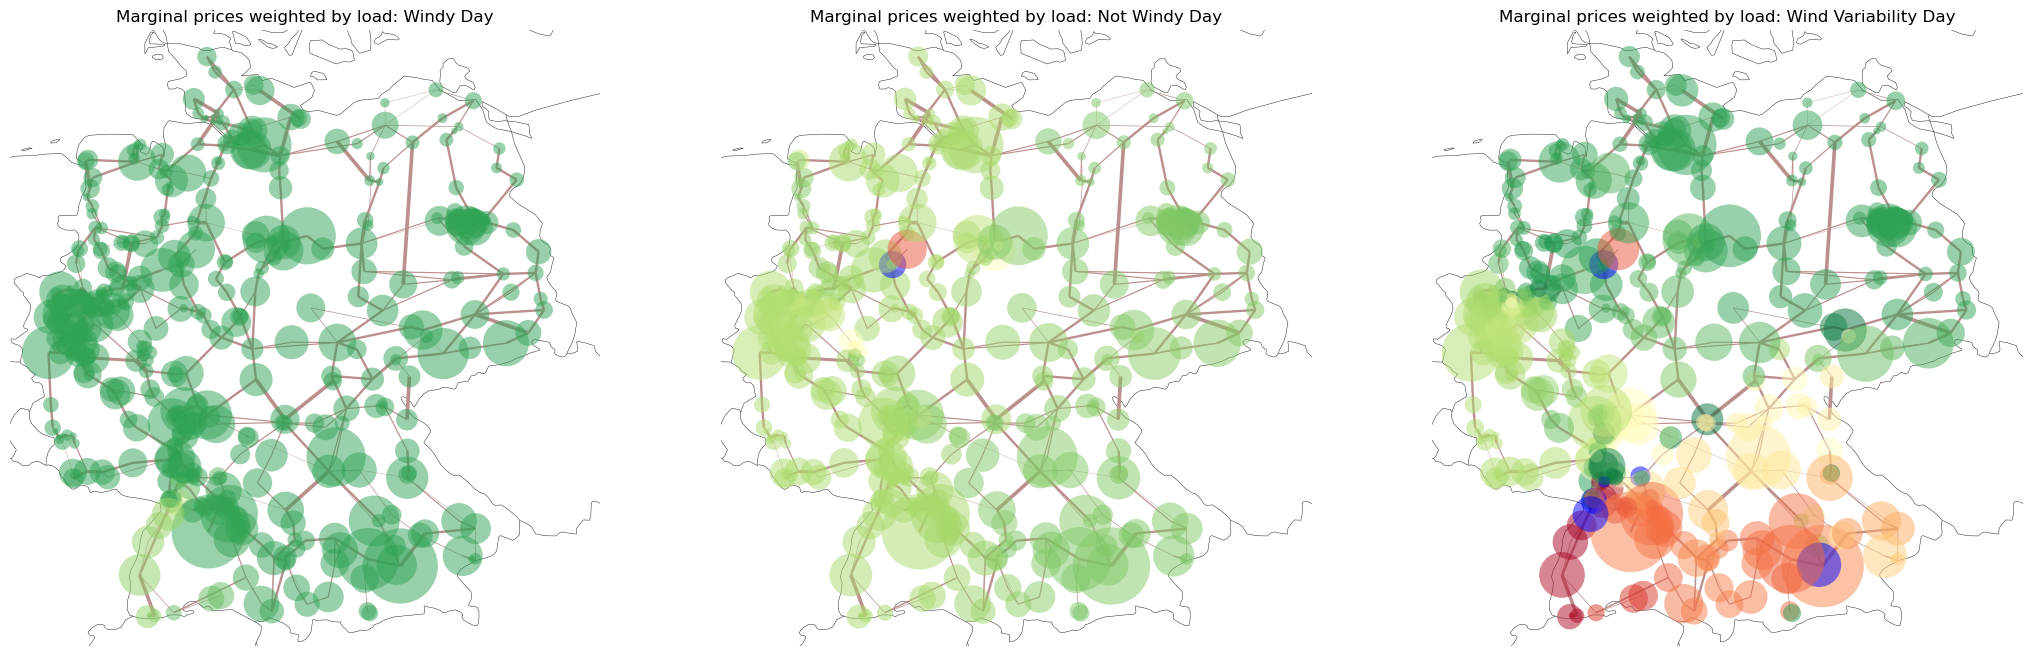

In [ ]:
# --- Create enhanced visualization ---
fig, axes = plt.subplots(1, 3, figsize=(26, 8), subplot_kw={"projection": ccrs.EqualEarth()})
fig.suptitle(f"Marginal Price Analysis ({folder})", fontsize=16)

# --- Define the normalization for the color map ---
NORMAL_PRICE = 93.15
HIGH_PRICE_THRESHOLD = 10000
GLOBAL_MIN = -32.34203267754546

vmin = GLOBAL_MIN
vmax = HIGH_PRICE_THRESHOLD

# Adjust vmin and vmax to ensure vcenter is not at the boundary
if vmin >= NORMAL_PRICE:
    vmin = NORMAL_PRICE - 1 
if vmax <= NORMAL_PRICE:
    vmax = NORMAL_PRICE + 1

marginal_price_norm = TwoSlopeNorm(
    vcenter=NORMAL_PRICE, vmin=vmin, vmax=vmax
)

# Get the colormap and set the color for values over the threshold
cmap = plt.get_cmap('RdYlGn_r').copy()
cmap.set_over('blue')


# --- Helper Function to Plot Network with Average Loading ---
def plot_marginal_prices(n, ax, title):
    from matplotlib.colors import TwoSlopeNorm
    avg_loading_n = (n.lines_t.p0.abs() / n.lines.s_nom).mean()
    avg_loading_links = (n.links_t.p0.abs() / n.links.p_nom).mean()
    
    # Calculate load at each bus by summing all loads attached to the same bus.
    bus_load = (
        n.loads_t.p_set.T.groupby(n.loads.bus).sum().T
        .reindex(columns=n.buses.index, fill_value=0.0)
    )
    
    # Find the time with the highest overall marginal price
    peak_price_time = n.buses_t.marginal_price.max(axis=1).idxmax()
    peak_prices = n.buses_t.marginal_price.loc[peak_price_time]
    bus_load_at_peak = bus_load.loc[peak_price_time]
    log_print(f"Plotting '{n.name}' network at time {peak_price_time} with peak marginal price {peak_prices.max():.2f} €/MWh")

    min_prices = n.buses_t.marginal_price.loc[peak_price_time]
    log_print(f"Minimum marginal price across all buses at peak time: {min_prices.min():.2f} €/MWh")
    
    n.plot(
        ax=ax,
        geomap=True,
        title=title,
        bus_sizes=bus_load_at_peak / 6000,
        bus_colors=peak_prices,
        bus_cmap=cmap,
        bus_cmap_norm=marginal_price_norm,
        bus_alpha=0.5,
        link_colors=avg_loading_links,
        line_cmap="YlOrRd",
        link_cmap="RdYlGn_r",
        link_alpha=0.0,
        line_width=n.lines.s_nom / 2000,
        link_width=n.links.p_nom / 2000,
    )
    return peak_prices

# Plot Average Loading Over All Snapshots for each network
i = 0
for n in networks.values():
    peak_prices = plot_marginal_prices(n, axes[i], "Marginal prices weighted by load: " + n.name + " Day")
    log_print(f"\n{n.name} Marginal Price Statistics:")
    log_print(peak_prices.describe().to_string())
    log_print(f"Peak marginal price range: {peak_prices.min():.2f} to {peak_prices.max():.2f} €/MWh")
    log_print("")
    i += 1

fig.tight_layout(rect=[0, 0, 1, 0.96])
save_fig(fig, "marginal_prices_weighted.png")

##### Marginal Prices

Plotting 'Windy' network at time 2025-10-26 08:00:00 with peak marginal price 81.06 €/MWh
Minimum marginal price across all buses at peak time: -8.36 €/MWh


/home/lucakristin/miniconda3/envs/pypsa-eur/lib/python3.13/site-packages/matplotlib/colors.py:2295: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)



Windy Marginal Price Statistics:
count    1350.000000
mean        6.577958
std        10.337579
min        -8.363250
25%         0.025995
50%         0.056539
75%        12.750287
max        81.063886

Plotting 'Not Windy' network at time 2025-04-08 19:00:00 with peak marginal price 10000.01 €/MWh
Minimum marginal price across all buses at peak time: 11.65 €/MWh


/home/lucakristin/miniconda3/envs/pypsa-eur/lib/python3.13/site-packages/matplotlib/colors.py:2295: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)



Not Windy Marginal Price Statistics:
count     1350.000000
mean        75.929135
std        516.990197
min         11.652290
25%         33.000476
50%         44.360346
75%         46.996999
max      10000.009907

Plotting 'Wind Variability' network at time 2025-10-06 05:00:00 with peak marginal price 10000.01 €/MWh
Minimum marginal price across all buses at peak time: -28.75 €/MWh


/home/lucakristin/miniconda3/envs/pypsa-eur/lib/python3.13/site-packages/matplotlib/colors.py:2295: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)



Wind Variability Marginal Price Statistics:
count     1350.000000
mean      1046.421591
std       2305.603622
min        -28.749948
25%          2.516078
50%         36.753330
75%         81.345434
max      10000.010692

Saved figure: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/analysis/germany_scenario2040-TP_/02_marginal_prices.png


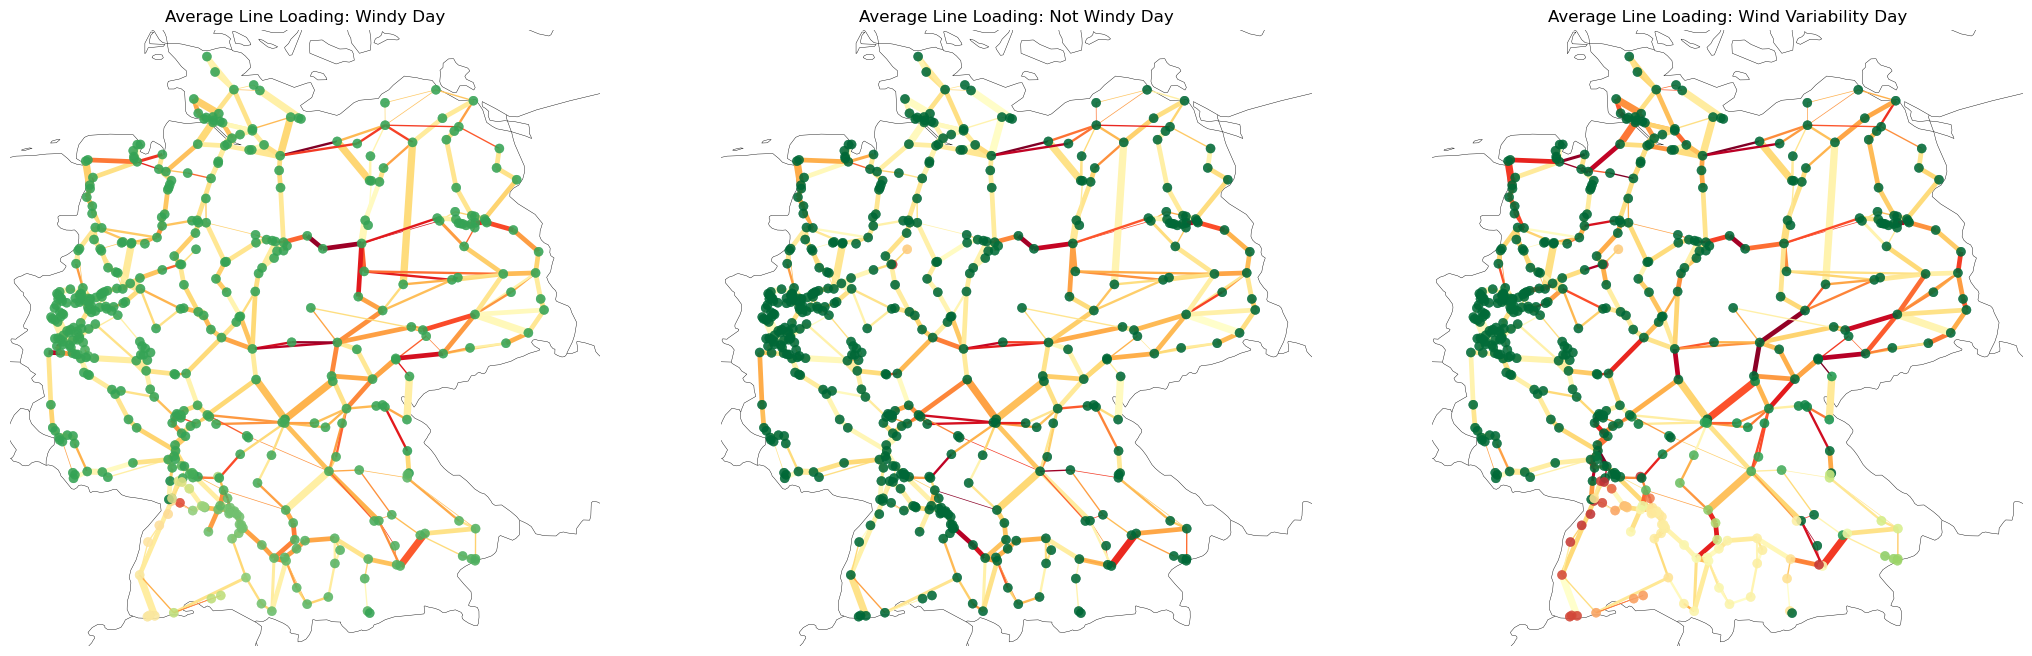

In [ ]:
# --- Create enhanced visualization ---
fig, axes = plt.subplots(1, 3, figsize=(26, 8), subplot_kw={"projection": ccrs.EqualEarth()})
fig.suptitle(f"Marginal Prices at Peak Time ({folder})", fontsize=16)

# --- Helper Function to Plot Network with Average Loading ---
def plot_network_congestion(n, ax, title):
    avg_loading_n = (n.lines_t.p0.abs() / n.lines.s_nom).mean()
    avg_loading_links = (n.links_t.p0.abs() / n.links.p_nom).mean()
    
    # Find the time with the highest overall marginal price
    peak_price_time = n.buses_t.marginal_price.max(axis=1).idxmax()
    peak_prices = n.buses_t.marginal_price.loc[peak_price_time]
    log_print(f"Plotting '{n.name}' network at time {peak_price_time} with peak marginal price {peak_prices.max():.2f} €/MWh")

    min_prices = n.buses_t.marginal_price.loc[peak_price_time]
    log_print(f"Minimum marginal price across all buses at peak time: {min_prices.min():.2f} €/MWh")
    
    n.plot(
        ax=ax,
        geomap=True,
        title=title,
        bus_sizes=0.005,
        bus_colors=peak_prices,
        bus_cmap='RdYlGn_r',
        bus_alpha=0.5,
        line_colors=avg_loading_n,
        link_colors=avg_loading_links,
        line_cmap="YlOrRd",
        link_cmap="RdYlGn_r",
        link_alpha=0.0,
        line_width=n.lines.s_nom / 1000,
        link_width=n.links.p_nom / 1000,
    )

    return peak_prices

# Plot Average Loading Over All Snapshots for each network
i = 0
for n in networks.values():
    peak_prices = plot_network_congestion(n, axes[i], "Average Line Loading: " + n.name + " Day")
    log_print(f"\n{n.name} Marginal Price Statistics:")
    log_print(peak_prices.describe().to_string())
    log_print("")
    i += 1

fig.tight_layout(rect=[0, 0, 1, 0.96])
save_fig(fig, "02_marginal_prices.png")

##### Average Marginal Price by Snapshot

Network: Windy
count    24.000000
mean      5.826909
std       2.982587
min       1.251381
25%       2.115930
50%       7.239928
75%       7.813887
max      10.034601

Network: Not Windy
count     24.000000
mean      98.497279
std       14.420957
min       69.598218
25%       82.608912
50%      108.787897
75%      109.050355
max      109.282341

Network: Wind Variability
count      24.000000
mean     1686.835094
std        27.964087
min      1645.259245
25%      1668.299657
50%      1677.313038
75%      1712.081149
max      1724.830915

Saved figure: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/analysis/germany_scenario2040-TP_/02_average_marginal_prices.png


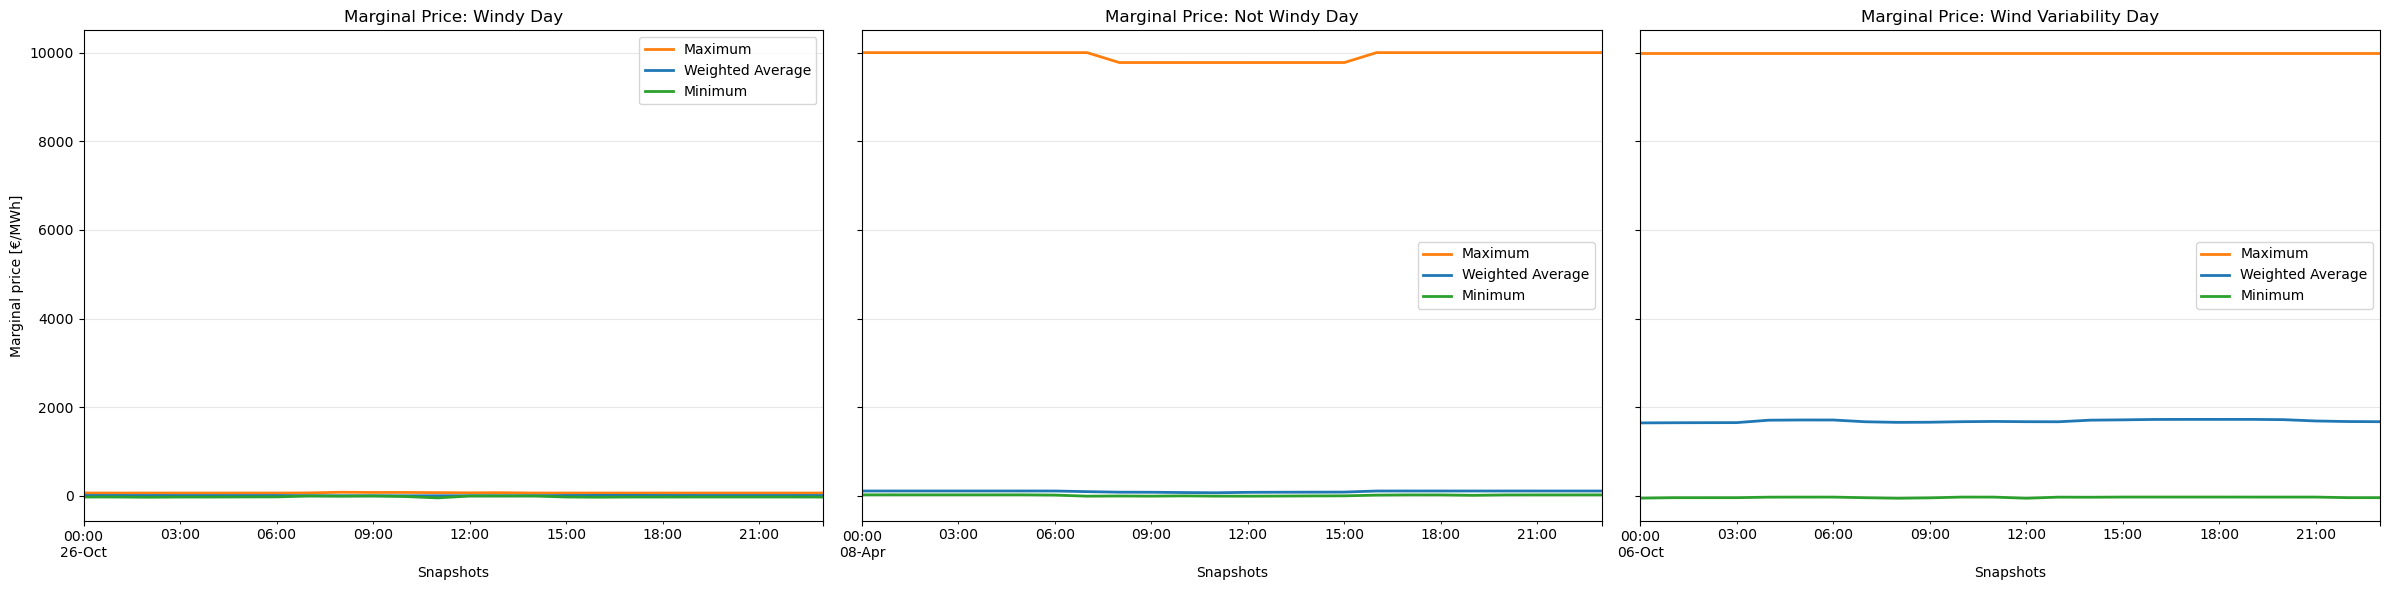

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(24, 6), sharey=True)
fig.suptitle(f"Marginal Price Over Time ({folder})", fontsize=16)

for ax, network in zip(axes, [n1, n2, n3]):
    if network.buses_t.marginal_price.empty:
        avg_marginal_price = pd.Series(0.0, index=network.snapshots)
        min_marginal_price = pd.Series(0.0, index=network.snapshots)
        max_marginal_price = pd.Series(0.0, index=network.snapshots)
        log_print(f"No marginal price data found for {network.name}.")
    else:
        # Calculate load-weighted average marginal price
        prices = network.buses_t.marginal_price
        # Aggregate loads per bus
        bus_loads = network.loads_t.p_set.T.groupby(network.loads.bus).sum().T
        # Ensure bus_loads has the same columns as prices, filling missing with 0
        bus_loads = bus_loads.reindex(columns=prices.columns, fill_value=0.0)
        
        total_load = bus_loads.sum(axis=1)
        # Avoid division by zero for snapshots with no load
        weighted_avg_price = (prices * bus_loads).sum(axis=1) / total_load.where(total_load != 0, 1)
        
        avg_marginal_price = weighted_avg_price
        min_marginal_price = network.buses_t.marginal_price.min(axis=1)
        max_marginal_price = network.buses_t.marginal_price.max(axis=1)
    
    max_marginal_price.plot(ax=ax, color="tab:orange", lw=2)
    avg_marginal_price.plot(ax=ax, color="tab:blue", lw=2)
    min_marginal_price.plot(ax=ax, color="tab:green", lw=2)
   
    ax.set_title(f"Marginal Price: {network.name} Day" )
    ax.set_xlabel("Snapshots")
    ax.set_ylabel("Marginal price [€/MWh]")
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend(["Maximum", "Weighted Average", "Minimum"])

    log_print("=" * 70)
    log_print(f"Network: {network.name}")
    log_print(avg_marginal_price.describe().to_string())
    log_print("=" * 70)
    log_print("")

fig.tight_layout(rect=[0, 0, 1, 0.96])
save_fig(fig, "02_average_marginal_prices.png")

### Load shedding

 Network: Windy
  Average loading across all lines: 18.59%
  Max average loading: 66.41%
  Lines with >60% avg loading: 4
  Lines with >70% avg loading: 0

 Network: Not Windy
  Average loading across all lines: 16.15%
  Max average loading: 68.81%
  Lines with >60% avg loading: 5
  Lines with >70% avg loading: 0

 Network: Wind Variability
  Average loading across all lines: 21.35%
  Max average loading: 68.98%
  Lines with >60% avg loading: 20
  Lines with >70% avg loading: 0

Saved figure: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/analysis/germany_scenario2040-TP_/03_load_shedding.png


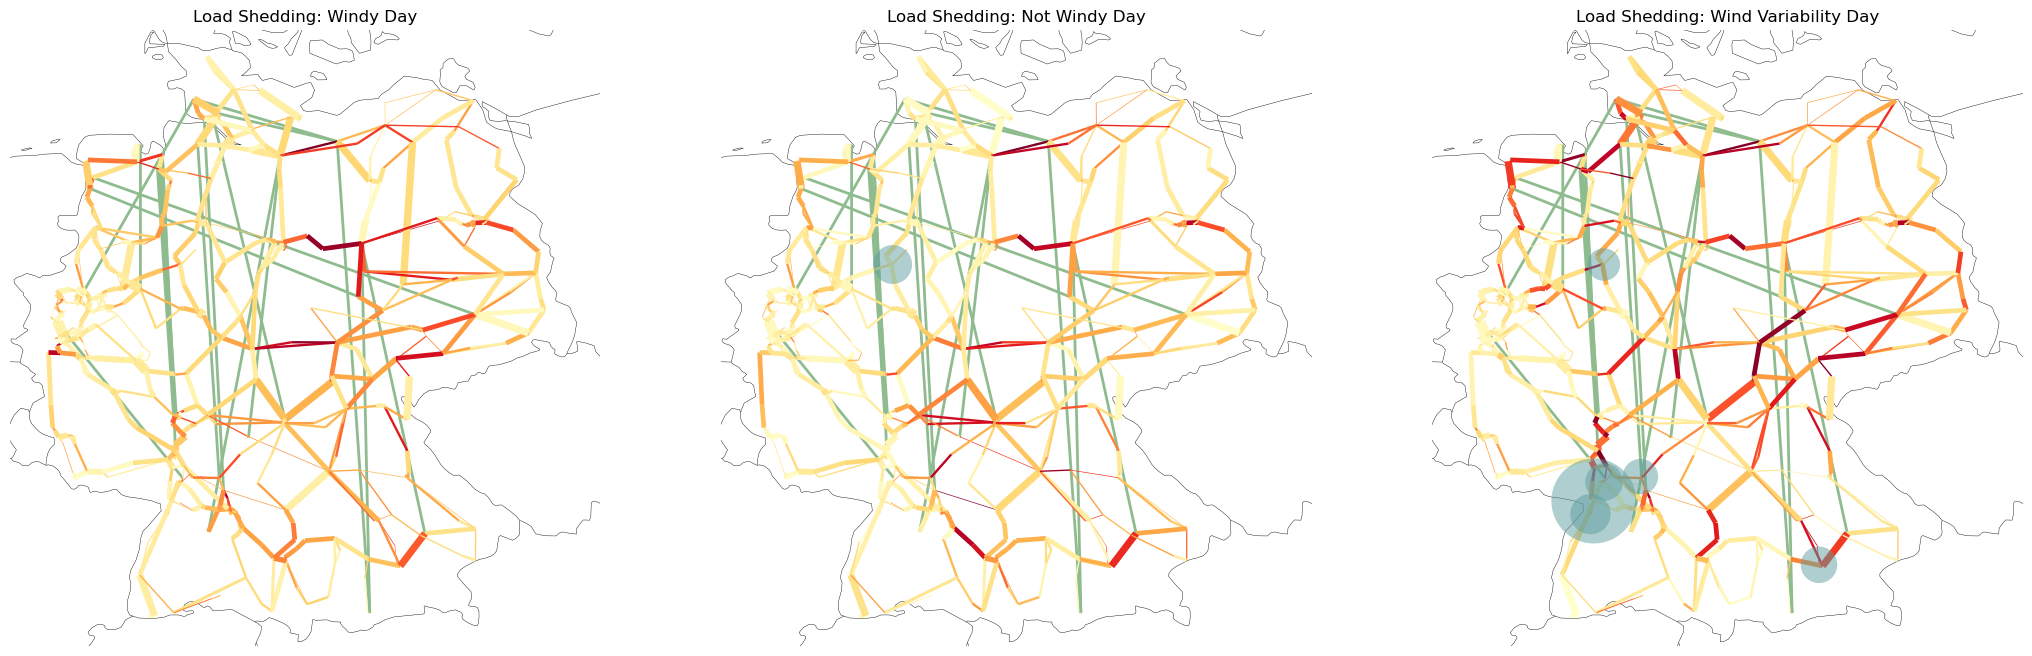

In [ ]:
# --- Create enhanced visualization ---
fig, axes = plt.subplots(1, 3, figsize=(26, 8), subplot_kw={"projection": ccrs.EqualEarth()})
fig.suptitle(f"Load Shedding Analysis ({folder})", fontsize=16)

# --- Helper Function to Plot Network with Average Loading ---
def plot_network_load(n, ax, title):
    avg_loading_n = (n.lines_t.p0.abs() / n.lines.s_nom).mean()
    load_mask = n.generators.carrier.str.contains("load", case=False, na=False)
    shed_gens = n.generators.index[load_mask]

    if len(shed_gens) == 0:
        log_print("No generator carrier containing 'load' found. Plot will show zeros.")
        shed_by_bus_time = pd.DataFrame(
            0.0, index=n.snapshots, columns=n.buses.index
        )
    else:
        # Time series of unmet load aggregated by bus [MW].
        shed_by_bus_time = (
            n.generators_t.p[shed_gens]
            .T.groupby(n.generators.loc[shed_gens, "bus"])
            .sum()
            .T
            .reindex(columns=n.buses.index, fill_value=0.0)
        )

    # Pick the snapshot with the highest system-wide unmet load.
    total_shed = shed_by_bus_time.sum(axis=1)
    worst_shed_snapshot = total_shed.idxmax()
    unmet_load_at_snapshot = shed_by_bus_time.loc[worst_shed_snapshot]
    
    n.plot(
        ax=ax,
        geomap=True,
        title=title,
        bus_sizes=unmet_load_at_snapshot/3000,
        bus_alpha=0.5,
        bus_cmap="YlOrRd",
        line_colors=avg_loading_n,
        line_cmap="YlOrRd",
        line_width=n.lines.s_nom / 1000,
        link_width=n.links.p_nom / 1000 if not n.links.empty else 0,
    )

    return avg_loading_n

# Plot Average Loading Over All Snapshots for each network
i = 0
for n in networks.values():
    avg_loading = plot_network_load(n, axes[i], "Load Shedding: " + n.name + " Day")
    log_print("=" * 70)
    log_print(f" Network: {n.name}")
    log_print(f"  Average loading across all lines: {avg_loading.mean():.2%}")
    log_print(f"  Max average loading: {avg_loading.max():.2%}")
    log_print(f"  Lines with >60% avg loading: {(avg_loading > 0.6).sum()}")
    log_print(f"  Lines with >70% avg loading: {(avg_loading > 0.7).sum()}")
    log_print("=" * 70)
    log_print("")
    i += 1

fig.tight_layout(rect=[0, 0, 1, 0.96])
save_fig(fig, "03_load_shedding.png")

In [388]:
n.links.groupby("carrier").sum()

,bus0,bus1,type,efficiency,active,build_year,lifetime,p_nom,p_nom_mod,p_nom_extendable,...,p_nom_opt,voltage,geometry,under_construction,underground,dc,underwater_fraction,project_status,tags,reversed
carrier,,,,,,,,,,,,,,,,,,,,,
DC,DE0 264DE0 388DE0 375DE0 125DE0 232DE0 111DE0 ...,DE0 3DE0 299DE0 323DE0 62DE0 79DE0 292DE0 138D...,,18.000000,18,36580,inf,38000.0,0.0,0,...,38000.000000,0.0,"LINESTRING (9.1395423 53.8972549, 9.1258701 49...",18.0,16.0,0.0,0.13,confirmedconfirmedin_permittingin_permittingco...,"""url""=>""https://tyndp2020-project-platform.azu...",0
H2 Electrolysis,DE0 0DE0 1DE0 10DE0 100DE0 101DE0 102DE0 103DE...,DE0 0 H2DE0 1 H2DE0 10 H2DE0 100 H2DE0 101 H2D...,,314.730000,450,0,11250.0,0.0,0.0,450,...,11336.469005,0.0,,0.0,0.0,0.0,0.00,,,0
H2 Fuel Cell,DE0 0 H2DE0 1 H2DE0 10 H2DE0 100 H2DE0 101 H2D...,DE0 0DE0 1DE0 10DE0 100DE0 101DE0 102DE0 103DE...,,225.000000,450,0,4500.0,0.0,0.0,450,...,19136.251860,0.0,,0.0,0.0,0.0,0.00,,,0
battery charger,DE0 0DE0 1DE0 10DE0 100DE0 101DE0 102DE0 103DE...,DE0 0 batteryDE0 1 batteryDE0 10 batteryDE0 10...,,440.908154,450,0,4500.0,0.0,0.0,450,...,25588.635260,0.0,,0.0,0.0,0.0,0.00,,,0
battery discharger,DE0 0 batteryDE0 1 batteryDE0 10 batteryDE0 10...,DE0 0DE0 1DE0 10DE0 100DE0 101DE0 102DE0 103DE...,,440.908154,450,0,4500.0,0.0,0.0,450,...,26116.291501,0.0,,0.0,0.0,0.0,0.00,,,0


##### Offshore Wind Curtailment


#### Parameter Documentation for New Curtailment Function

**Parameters Used:**

1. **`generators.p_nom`** (static, MW) — Installed/nameplate capacity
   - *Why:* Represents the fixed maximum power the generator can produce (unless extendable).
   - *Used when:* Generator capacity was not optimized.

2. **`generators.p_nom_opt`** (output, MW) — Optimized capacity after solving
   - *Why:* After optimization, if `p_nom_extendable=True`, this holds the actual capacity built. For post-solve analysis, we should use this.
   - *Fallback:* If `p_nom_opt` is NaN, we fall back to `p_nom`.
   - **This is the key fix:** The old function ignored optimization, always using `p_nom`.

3. **`generators_t.p_max_pu`** (time series, per unit, 0-1) — Maximum output availability factor
   - *Why:* For renewables, this is the capacity factor from weather (wind speed, solar irradiance). For conventional plants, it's the de-rating factor (maintenance, forced outages, etc.).
   - *Formula:* Available Power[t] = `p_max_pu[t]` × `p_nom_eff`

4. **`generators_t.p`** (time series, MW) — Actual dispatched power (solver output)
   - *Why:* This is what was actually generated. Curtailment = Available − Dispatched.

5. **`generators.carrier`** (string) — Energy carrier type (e.g., 'onwind', 'offwind-ac', 'solar')
   - *Why:* Allows filtering/grouping by technology type for separate analysis.

**The Curtailment Equation:**

$$\text{Curtailed Power}[t] = \max\left(0, \, p\_max\_pu[t] \times p\_nom\_eff \, - \, p[t] \right)$$

where $p\_nom\_eff = p\_nom\_opt$ if extendable (and not NaN), otherwise $p\_nom$.


In [389]:
def plot_curtailment(n, carrier, ax):
    # Time-series available / dispatched / curtailed aggregated by carrier
    p_available_by_carrier = (
        n.generators_t.p_max_pu.multiply(n.generators.p_nom).T.groupby(n.generators.carrier).sum().T
    )
    p_by_carrier = n.generators_t.p.T.groupby(n.generators.carrier).sum().T
    p_curtailed_by_carrier = (p_available_by_carrier - p_by_carrier).clip(lower=0)

    # Use friendly display name for the title, but keep the legend generic.
    carrier_display = carrier_label(carrier)
    capacity = n.generators.groupby("carrier")["p_nom"].sum().at[carrier]

    # Build a dataframe for plotting while keeping the legend labels generic.
    p_df = pd.DataFrame(
        {
            "dispatched": p_by_carrier[carrier],
            "curtailed": p_curtailed_by_carrier[carrier],
            "available": p_available_by_carrier[carrier],
        }
    )
    p_df["capacity"] = capacity

    # Plot stacked dispatched + curtailed area, then available and capacity lines
    p_df[["dispatched", "curtailed"]].plot(kind="area", ax=ax, lw=0, legend=False)
    p_df[["available", "capacity"]].plot(ax=ax, legend=False)

    # Compute totals for logging
    p_available = n.generators_t.p_max_pu.multiply(n.generators.p_nom)
    p_av_by = p_available.T.groupby(n.generators.carrier).sum().T
    p_disp_by = n.generators_t.p.T.groupby(n.generators.carrier).sum().T
    p_cur = (p_av_by - p_disp_by).clip(lower=0)

    tot_av = p_av_by[carrier].sum()
    tot_disp = p_disp_by[carrier].sum()
    tot_cur = p_cur[carrier].sum()

    # Axis formatting and explicit generic legend handles.
    ax.set_xlabel("")
    ax.set_ylabel("Power [MW]")
    ax.set_ylim([0, p_df["capacity"].max() * 1.1 if hasattr(p_df["capacity"], "max") else None])
    ax.set_title(f"{carrier_display} Curtailment: {n.name} Day")

    legend_handles = [
        Patch(facecolor="tab:blue", edgecolor="none", label="dispatched"),
        Patch(facecolor="tab:orange", edgecolor="none", label="curtailed"),
        Line2D([0], [0], color="tab:green", lw=2, label="available"),
        Line2D([0], [0], color="tab:red", lw=2, label="capacity"),
    ]
    ax.legend(handles=legend_handles, loc="upper center", ncol=2, bbox_to_anchor=(0.5, -0.12), frameon=False)

    # Log summary using display-name
    log_print("=" * 70)
    log_print(f"Network: {n.name}")
    log_print(f"{carrier_display} capacity MW: {n.generators.groupby('carrier')['p_nom'].sum().get(carrier):.2f}")
    log_print(f"Total available (MWh): {tot_av:.2f}")
    log_print(f"Total dispatched (MWh): {tot_disp:.2f}")
    log_print(f"Total curtailed (MWh): {tot_cur:.2f}")
    log_print(f"Curtailed fraction: {tot_cur / tot_av if tot_av else float('nan'):.2f}")
    log_print("=" * 70)
    log_print("")

#### offwind

Network: Windy
Offshore wind (AC) capacity MW: 66000.00
Total available (MWh): 1396386.72
Total dispatched (MWh): 79293.17
Total curtailed (MWh): 1317093.56
Curtailed fraction: 0.94

Network: Not Windy
Offshore wind (AC) capacity MW: 66000.00
Total available (MWh): 50461.94
Total dispatched (MWh): 50448.02
Total curtailed (MWh): 13.93
Curtailed fraction: 0.00

Network: Wind Variability
Offshore wind (AC) capacity MW: 66000.00
Total available (MWh): 1018437.16
Total dispatched (MWh): 201362.06
Total curtailed (MWh): 817075.09
Curtailed fraction: 0.80

Saved figure: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/analysis/germany_scenario2040-TP_/04_offwind_curtailment.png


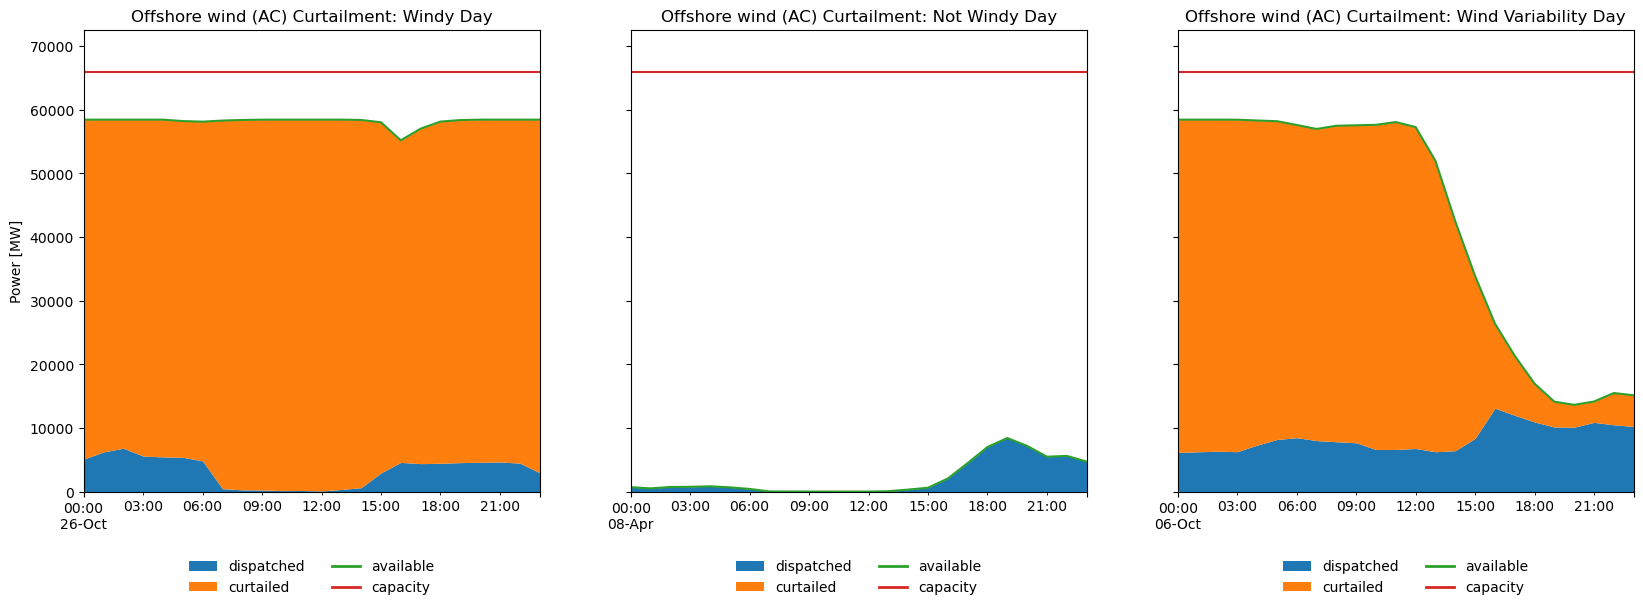

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
fig.suptitle(f"Offshore Wind Curtailment ({folder})", fontsize=16)

plot_curtailment(n1, "offwind-ac", axes[0])
plot_curtailment(n2, "offwind-ac", axes[1])
plot_curtailment(n3, "offwind-ac", axes[2])

fig.tight_layout(rect=[0, 0, 1, 0.96])
save_fig(fig, "04_offwind_curtailment.png")

#### onwind

Network: Windy
Onshore wind capacity MW: 209000.00
Total available (MWh): 4335851.88
Total dispatched (MWh): 1329136.42
Total curtailed (MWh): 3006715.46
Curtailed fraction: 0.69

Network: Not Windy
Onshore wind capacity MW: 209000.00
Total available (MWh): 140587.04
Total dispatched (MWh): 138943.24
Total curtailed (MWh): 1643.79
Curtailed fraction: 0.01

Network: Wind Variability
Onshore wind capacity MW: 209000.00
Total available (MWh): 2299928.50
Total dispatched (MWh): 1405116.55
Total curtailed (MWh): 894811.96
Curtailed fraction: 0.39

Saved figure: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/analysis/germany_scenario2040-TP_/05_onwind_curtailment.png


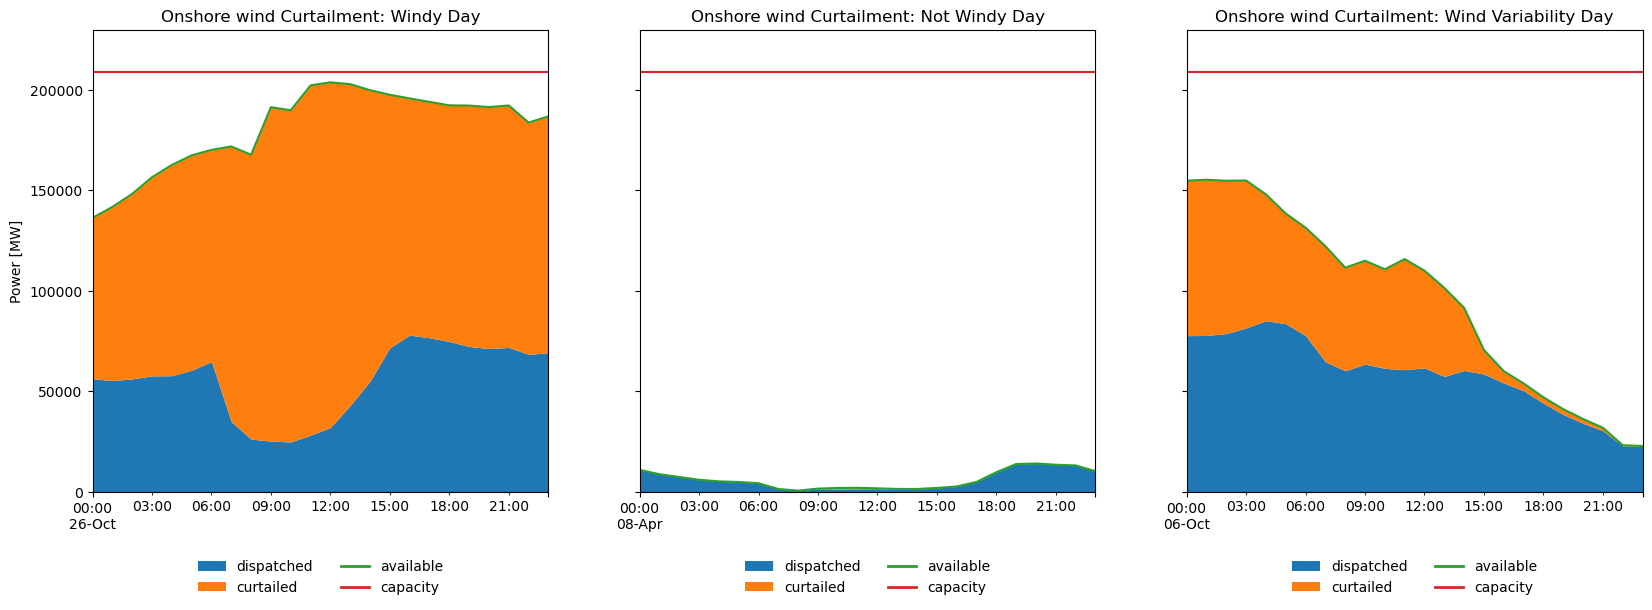

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
fig.suptitle(f"Onshore Wind Curtailment ({folder})", fontsize=16)

plot_curtailment(n1, "onwind", axes[0])
plot_curtailment(n2, "onwind", axes[1])
plot_curtailment(n3, "onwind", axes[2])

fig.tight_layout(rect=[0, 0, 1, 0.96])
save_fig(fig, "05_onwind_curtailment.png")

#### solar

Network: Windy
Solar PV capacity MW: 367000.00
Total available (MWh): 517185.46
Total dispatched (MWh): 426409.39
Total curtailed (MWh): 90776.06
Curtailed fraction: 0.18

Network: Not Windy
Solar PV capacity MW: 367000.00
Total available (MWh): 1861419.31
Total dispatched (MWh): 1620764.81
Total curtailed (MWh): 240654.51
Curtailed fraction: 0.13

Network: Wind Variability
Solar PV capacity MW: 367000.00
Total available (MWh): 382596.34
Total dispatched (MWh): 302914.86
Total curtailed (MWh): 79681.48
Curtailed fraction: 0.21

Saved figure: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/analysis/germany_scenario2040-TP_/05_solar_curtailment.png


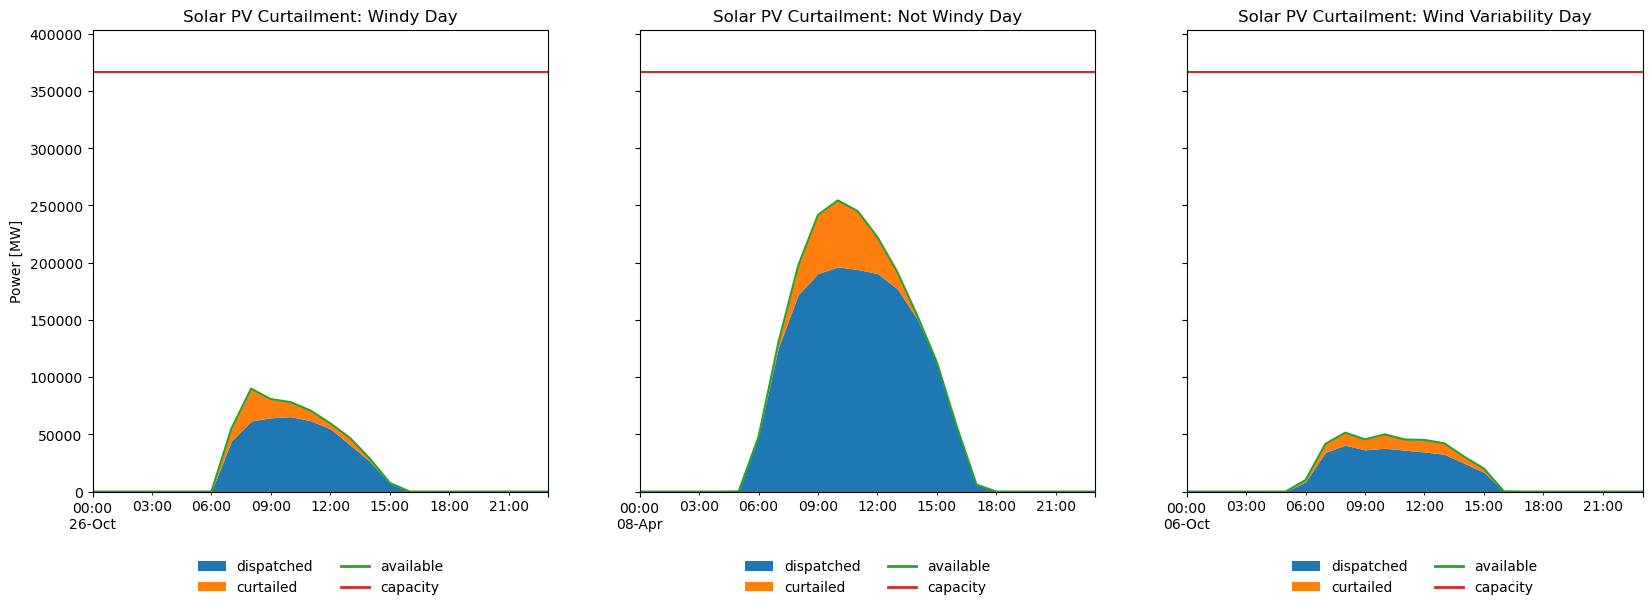

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
fig.suptitle(f"Solar Curtailment ({folder})", fontsize=16)

plot_curtailment(n1, "solar", axes[0])
plot_curtailment(n2, "solar", axes[1])
plot_curtailment(n3, "solar", axes[2])

fig.tight_layout(rect=[0, 0, 1, 0.96])
save_fig(fig, "05_solar_curtailment.png")

### 4.2 Generation and Capacity Comparison

##### Power Dispatch by Carrier

Saved figure: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/analysis/germany_scenario2040-TP_/06_power_dispatch.png


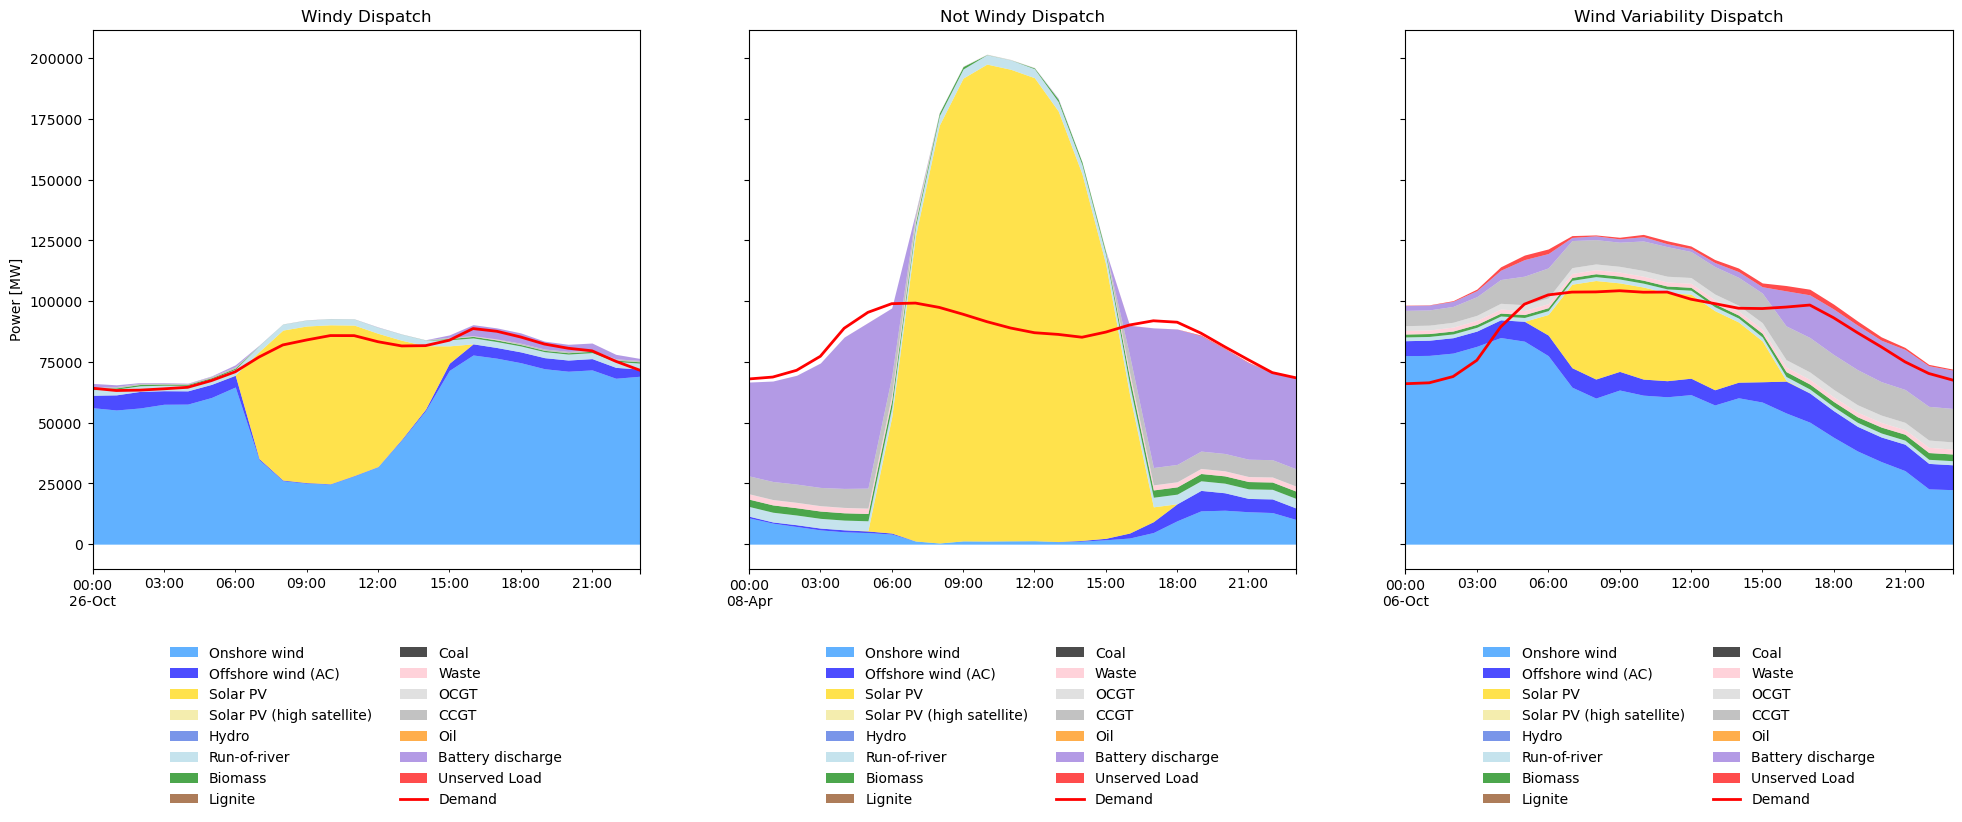

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(24, 7), sharey=True)
fig.suptitle(f"Power Dispatch by Carrier ({folder})", fontsize=16)

# --- Define Colors and Order ---
colors = {
    # Wind
    "onwind": "dodgerblue",
    "offwind-ac": "blue",
    "offwind-float": "steelblue",
    # Solar
    "solar": "gold",
    "solar-hsat": "khaki",
    # Hydro
    "hydro": "royalblue",
    "ror": "lightblue",
    # Fossil Fuels
    "lignite": "saddlebrown",
    "coal": "black",
    "oil": "darkorange",
    "OCGT": "lightgray",
    "CCGT": "darkgray",
    # Other
    "biomass": "green",
    "waste": "pink",
    #"geothermal": "firebrick",
    "battery discharge": "mediumpurple",
    "load": "red"
}

cols = [
    # Renewables
    "onwind", "offwind-ac", 
    "solar", "solar-hsat",
    "hydro", "ror",
    "biomass", #"geothermal",
    # Conventional
    "lignite", "coal", "waste",
    "OCGT", "CCGT", "oil",
    # Storage
    "battery discharge",
    "load"
]

# --- Helper function for plotting ---
def plot_dispatch(n, ax, title):
    p_by_carrier = n.generators_t.p.T.groupby(n.generators.carrier).sum().T

    # Add battery discharge as another stacked supply source on the electricity side
    battery_discharge_dispatch = pd.Series(0.0, index=n.snapshots)
    if not n.links.empty and "battery discharger" in set(n.links.carrier):
        battery_discharge_dispatch = -n.links_t.p1.loc[:, n.links.carrier == "battery discharger"].sum(axis=1)

    p_by_carrier["battery discharge"] = battery_discharge_dispatch

    # Reorder and fill missing columns
    p_by_carrier = p_by_carrier.reindex(columns=cols).fillna(0)

    # Get colors in the correct order
    c = [colors.get(col, "gray") for col in p_by_carrier.columns]
    p_by_carrier.columns = [carrier_label(col) for col in p_by_carrier.columns]

    p_by_carrier.plot(kind="area", ax=ax, lw=0, title=title, color=c, alpha=0.7)

    # Add demand curve
    demand = n.loads_t.p_set.sum(axis=1)
    demand.plot(ax=ax, color="red", lw=2, label="Demand")

    scenario_title = n.name

    real_data = pd.read_csv(
        f"/home/lucakristin/Desktop/my_pypsa/actual_electricity_data/combined_{scenario_title.replace(' ', '_').lower()}.csv",
        index_col=0,
        parse_dates=True,
    )
    real_data.index = pd.to_datetime(real_data.index)
    # Align to the network snapshots so missing hours do not break the plot
    demand_real = real_data["grid load"].reindex(n.snapshots)
    demand_real.name = "Actual Demand"
    # Shift real data by two hours
    if n.name == "Windy":
        demand_real = demand_real.shift(-1)
    else:
        demand_real = demand_real.shift(-2)
    #demand_real.plot(ax=ax, color="red", linestyle="--", lw=2, label="Actual Demand")

    ax.set_ylabel("Power [MW]")
    ax.set_xlabel("")
    ax.legend(ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.12), frameon=False)

# --- Plotting ---
plot_dispatch(n1, axes[0], "Windy Dispatch")
plot_dispatch(n2, axes[1], "Not Windy Dispatch")
plot_dispatch(n3, axes[2], "Wind Variability Dispatch")

fig.tight_layout(rect=[0, 0, 1, 0.96])
save_fig(fig, "06_power_dispatch.png")

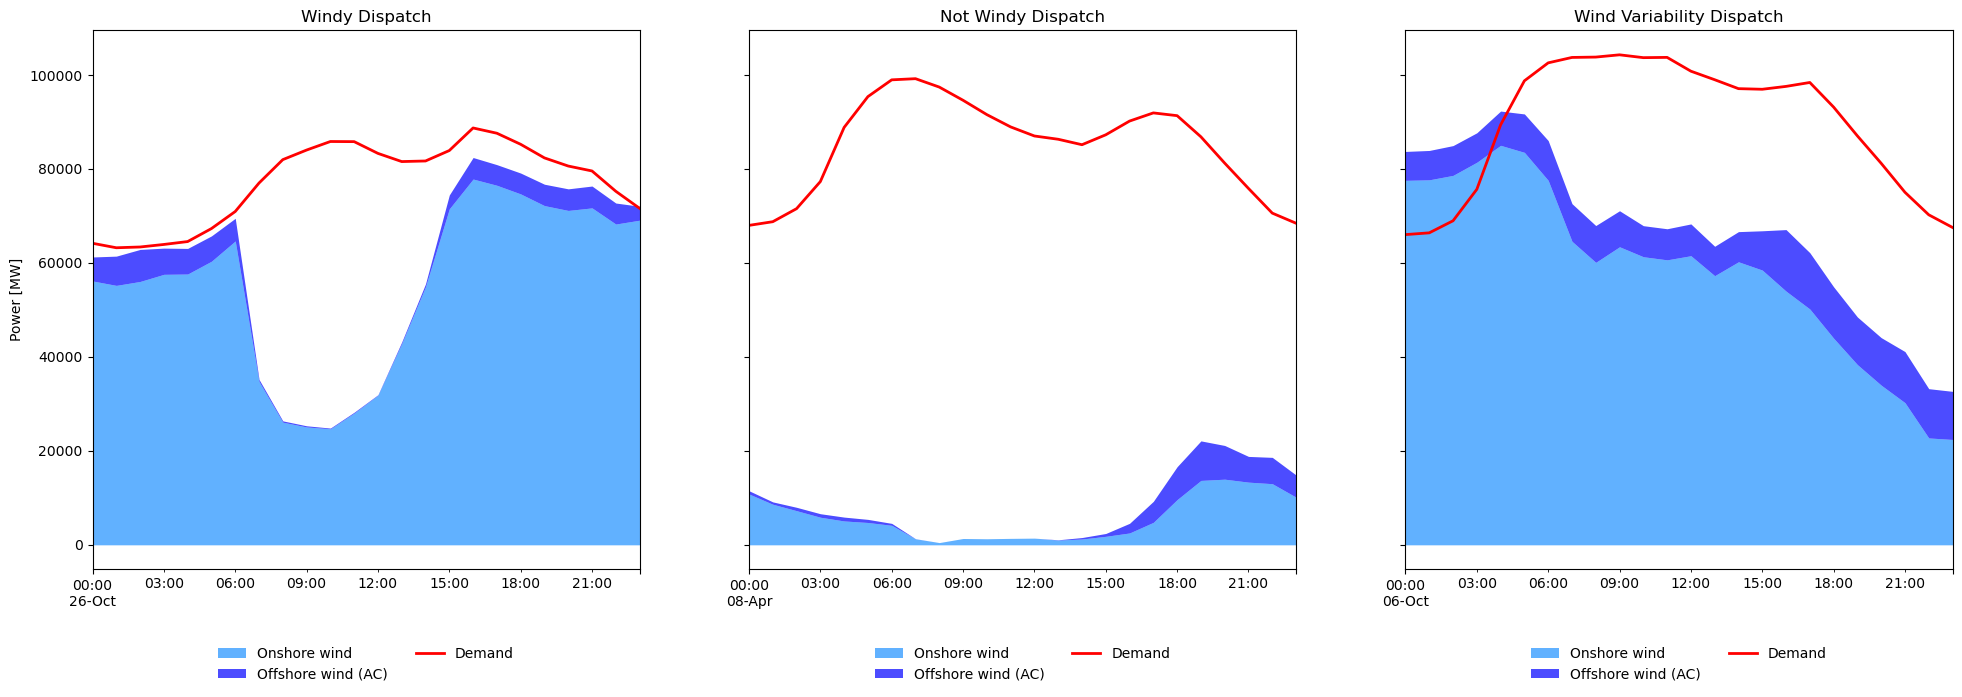

In [394]:
fig, axes = plt.subplots(1, 3, figsize=(24, 7), sharey=True)


cols = [
    # Renewables
    "onwind", "offwind-ac", 
]


# --- Plotting ---
plot_dispatch(n1, axes[0], "Windy Dispatch")
plot_dispatch(n2, axes[1], "Not Windy Dispatch")
plot_dispatch(n3, axes[2], "Wind Variability Dispatch")

##### Total Energy Production by Carrier

Saved figure: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/analysis/germany_scenario2040-TP_/07_energy_production.png

=== Energy Production Summary ===
                           Windy     Not Windy  Wind Variability
Onshore wind        1.329136e+06  1.389432e+05      1.405117e+06
Solar PV            4.264094e+05  1.620765e+06      3.029149e+05
CCGT                7.142497e+03  1.131472e+05      2.736399e+05
Offshore wind (AC)  7.929317e+04  5.044802e+04      2.013621e+05
Run-of-river        5.801393e+04  9.425793e+04      3.868849e+04
Biomass             8.700844e+03  5.206079e+04      3.829089e+04
Waste               9.059963e+02  3.338698e+04      4.180394e+04
OCGT                1.408503e+02  1.405360e+03      6.096122e+04
Unserved Load       9.710586e-04  1.023734e+03      2.693581e+04
Geothermal          4.582228e+02  6.431205e+02      4.586955e+02




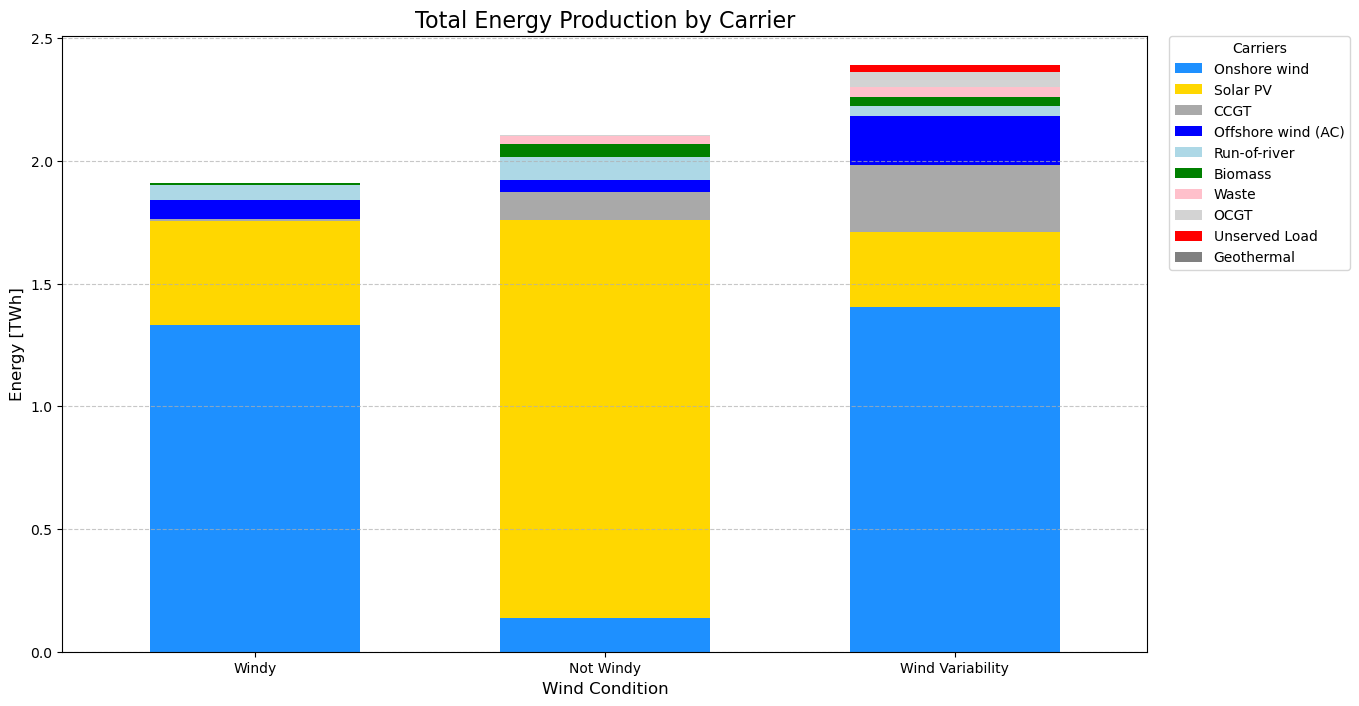

In [ ]:
# --- Calculate energy production for each scenario ---
p_by_carrier_n1 = n1.generators_t.p.sum().groupby(n1.generators.carrier).sum()
p_by_carrier_n2 = n2.generators_t.p.sum().groupby(n2.generators.carrier).sum()
p_by_carrier_n3 = n3.generators_t.p.sum().groupby(n3.generators.carrier).sum()

# --- Create a DataFrame for plotting ---
energy_df = pd.DataFrame({
    "Windy": p_by_carrier_n1,
    "Not Windy": p_by_carrier_n2,
    "Wind Variability": p_by_carrier_n3
}).fillna(0)

# Filter out carriers with negligible energy
energy_df = energy_df[energy_df.sum(axis=1) > 0.1]

# --- Sort carriers by total energy production (descending) ---
energy_df = energy_df.loc[energy_df.sum(axis=1).sort_values(ascending=False).index]
carrier_keys = list(energy_df.index)
energy_df.index = [carrier_label(carrier) for carrier in carrier_keys]

# Get colors for the carriers that are present
bar_colors = [colors.get(carrier, "grey") for carrier in carrier_keys]

# --- Plotting ---
fig, ax = plt.subplots(figsize=(14, 8))
fig.suptitle(f"Total Energy Production by Carrier ({folder})", fontsize=16)

# Plot stacked bar chart
(energy_df.T / 1e6).plot(kind="bar", stacked=True, ax=ax, color=bar_colors, width=0.6)

# --- Formatting ---
ax.set_title("Total Energy Production by Carrier", fontsize=16)
ax.set_ylabel("Energy [TWh]", fontsize=12)
ax.set_xlabel("Wind Condition", fontsize=12)
ax.tick_params(axis='x', rotation=0)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# --- Legend ---
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles, 
    labels, 
    title="Carriers",
    bbox_to_anchor=(1.02, 1), 
    loc='upper left', 
    borderaxespad=0.
)

fig.tight_layout(rect=[0, 0, 1, 0.96])
save_fig(fig, "07_energy_production.png")

# Log energy production summary
log_print("\n=== Energy Production Summary ===")
log_print(energy_df.to_string())
log_print("\n")

In [396]:
def calculate_emissions(n):
    emission_factors = n.c.carriers.static.co2_emissions
    emitting_generators = n.c.generators.static[
        n.c.generators.static.carrier.map(emission_factors).fillna(0) != 0
    ]
    generator_p = n.c.generators.dynamic.p.loc[:, emitting_generators.index]
    generator_efficiency = n.c.generators._as_dynamic("efficiency").loc[:, emitting_generators.index]
    snapshot_weightings = n.snapshot_weightings.generators.reindex(generator_p.index)
    emission_factors_per_generator = emitting_generators.carrier.map(emission_factors)
    co2_emissions = (
        generator_p.multiply(snapshot_weightings, axis=0)
        .multiply(emission_factors_per_generator, axis=1)
        .divide(generator_efficiency)
        .sum()
        .sum()
    )
    return co2_emissions

log_print("\n=== CO2 Emissions Summary ===")
for n in networks.values():
    log_print(f"Total CO2 emissions at the {n.name} day: {calculate_emissions(n):.2f} kg CO2")
log_print("\n")


=== CO2 Emissions Summary ===
Total CO2 emissions at the Windy day: 3562.11 kg CO2
Total CO2 emissions at the Not Windy day: 70634.69 kg CO2
Total CO2 emissions at the Wind Variability day: 170342.59 kg CO2




### Statistics

In [397]:
log_print("\n=== Network Statistics ===")
for n in networks.values():
    log_print(f"\nNetwork: {n.name}")
    log_print(n.statistics().to_string())
    log_print("\n")

log_print("\n=== Analysis Complete ===")
log_print(f"All results saved to: {analysis_dir}")


=== Network Statistics ===

Network: Windy
                                  Optimal Capacity  Installed Capacity        Supply    Withdrawal  Energy Balance  Transmission  Capacity Factor   Curtailment  Capital Expenditure  Operational Expenditure       Revenue  Market Value
Generator   Combined-Cycle Gas        2.900000e+04        2.900000e+04  7.142497e+03  0.000000e+00    7.142497e+03       0.00000         0.010262  6.888575e+05         1.004525e+07             343027.11687  3.479291e+05     48.712529
            Offshore Wind (AC)        6.600000e+04        6.600000e+04  7.929317e+04  0.000000e+00    7.929317e+04       0.00000         0.050059  1.317094e+06         5.121378e+07               1935.97276  1.935755e+03      0.024413
            Onshore Wind              2.090000e+05        2.090000e+05  1.329136e+06  0.000000e+00    1.329136e+06       0.00000         0.264979  3.006715e+06         6.803659e+07              33008.58849  2.653575e+06      1.996466
            Open-Cyc

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(8, 8), subplot_kw={"projection": ccrs.EqualEarth()})


n1.plot(
    ax=axes,
    geomap=True,
    bus_sizes=0,
    line_width=0,
    link_width=0,
)

In [ ]:
map = n1.explore()
map.to_html("exploring_base.html")